# MPI Scaling Analysis for the Monte Carlo Case Study

This notebook analyzes the MPI runs collected on LYRA for the Monte Carlo estimation of pi and the area of a circle or the volume of a sphere. The goal is to extract useful HPC performance indicators from `mc_results_mpi.txt`: execution time, speedup, efficiency, throughput, and numerical error.

A key point must be kept in mind: the current simulation stops when the pi estimate reaches a convergence threshold. This means that the total number of Monte Carlo points is not fixed across all runs. Therefore, the results are useful as an observed performance analysis, but they are not a perfectly controlled strong-scaling experiment.

## Metrics Used

Let `p` be the number of MPI processes and `T_p` the execution time measured with `p` processes.

- **Speedup** compares each parallel run with the serial baseline:

$$S(p) = \frac{T(1)}{T(p)}$$

- **Parallel efficiency** compares the measured speedup with the ideal speedup expected when increasing the number of processes:

$$E(p) = \frac{S(p)}{p}$$

- **Throughput** measures how many Monte Carlo points are processed per second:

$$throughput = \frac{N_{points}}{T_p}$$

Because the total number of points changes between runs, throughput is especially useful here: it normalizes the execution time by the actual amount of work performed.

In [1]:
from pathlib import Path
import math
import re

import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.figsize": (8, 4.8),
    "axes.titlesize": 14,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.frameon": True,
    "figure.dpi": 120,
})

## Load the LYRA Results

The parser below reads the text report generated by the MPI script. It is intentionally simple and works directly with the format written in `mc_results_mpi.txt`.

In [2]:
results_file = Path("mc_results_mpi.txt")
if not results_file.exists():
    raise FileNotFoundError("Could not find mc_results_mpi.txt in the current working directory.")

print(f"Reading results from: {results_file.resolve()}")
raw_text = results_file.read_text(encoding="utf-8")
print(raw_text[:500])

Reading results from: C:\Users\Riccardo\Documents\UNIMORE\High Performance Computing for Advanced Physical Analysis\Progetto\Phase 3 - Case Study\mc_results_mpi.txt
--- MONTE CARLO HPC REPORT ---
MPI Processes : 1
Total Points  : 20140000
Dimensions    : 3D
Radius        : 0.5
Pi Estimate   : 3.14159344587885
Final Volume    : 0.52359891
Compute Time  : 595.2358 seconds
--- MONTE CARLO HPC REPORT ---
MPI Processes : 2
Total Points  : 22260000
Dimensions    : 3D
Radius        : 0.5
Pi Estimate   : 3.14159299191375
Final Volume    : 0.52359883
Compute Time  : 364.6349 seconds
--- MONTE CARLO HPC REPORT ---
MPI Processes : 4
Total Points  : 16620000
Dimensions


In [3]:
def parse_montecarlo_report(text):
    blocks = text.split("--- MONTE CARLO HPC REPORT ---")
    rows = []

    for block in blocks:
        if not block.strip():
            continue

        values = {}
        for line in block.splitlines():
            if ":" not in line:
                continue
            key, value = line.split(":", 1)
            values[key.strip()] = value.strip()

        if not values:
            continue

        if "Final Area" in values:
            measure_type = "area"
            final_measure = float(values["Final Area"])
        elif "Final Volume" in values:
            measure_type = "volume"
            final_measure = float(values["Final Volume"])
        else:
            available_keys = ", ".join(values.keys())
            raise KeyError(f"Could not find Final Area or Final Volume in report block. Available keys: {available_keys}")

        rows.append({
            "mpi_processes": int(values["MPI Processes"]),
            "total_points": int(values["Total Points"]),
            "dimensions": int(re.search(r"\d+", values["Dimensions"]).group()),
            "radius": float(values["Radius"]),
            "pi_estimate": float(values["Pi Estimate"]),
            "measure_type": measure_type,
            "final_measure": final_measure,
            "compute_time_s": float(values["Compute Time"].split()[0]),
        })

    return sorted(rows, key=lambda row: row["mpi_processes"])


runs = parse_montecarlo_report(raw_text)
#runs


## Compute Scaling Indicators

The 1-process execution is used as the reference run, so the notebook now follows the standard strong-scaling definitions used in the course slides.

In [4]:
reference = runs[0]
if reference["mpi_processes"] != 1:
    raise ValueError("The first run must correspond to 1 MPI process for the standard strong-scaling analysis.")

t1 = reference["compute_time_s"]
throughput_ref = reference["total_points"] / reference["compute_time_s"]

for run in runs:
    run["points_per_process"] = run["total_points"] / run["mpi_processes"]
    run["pi_absolute_error"] = abs(run["pi_estimate"] - math.pi)
    run["throughput_points_s"] = run["total_points"] / run["compute_time_s"]
    run["speedup"] = t1 / run["compute_time_s"]
    run["ideal_speedup"] = run["mpi_processes"]
    run["efficiency"] = run["speedup"] / run["mpi_processes"]
    run["throughput_speedup"] = run["throughput_points_s"] / throughput_ref


def print_table(rows):
    header = (
        f"{'Proc':>5} | {'Dim':>3} | {'Measure':>7} | {'Points':>12} | {'Time [s]':>9} | "
        f"{'Speedup':>8} | {'Eff.':>6} | {'Throughput [pts/s]':>18} | {'Pi error':>10}"
    )
    print(header)
    print("-" * len(header))

    for row in rows:
        print(
            f"{row['mpi_processes']:5d} | "
            f"{row['dimensions']:3d} | "
            f"{row['measure_type']:>7} | "
            f"{row['total_points']:12,d} | "
            f"{row['compute_time_s']:9.4f} | "
            f"{row['speedup']:8.3f} | "
            f"{row['efficiency']:6.3f} | "
            f"{row['throughput_points_s']:18,.0f} | "
            f"{row['pi_absolute_error']:10.2e}"
        )


print_table(runs)

processes = [run["mpi_processes"] for run in runs]
times = [run["compute_time_s"] for run in runs]
total_points_millions = [run["total_points"] / 1_000_000 for run in runs]
speedups = [run["speedup"] for run in runs]
ideal_speedups = [run["ideal_speedup"] for run in runs]
efficiencies = [run["efficiency"] for run in runs]
throughput_millions = [run["throughput_points_s"] / 1_000_000 for run in runs]
throughput_speedups = [run["throughput_speedup"] for run in runs]


 Proc | Dim | Measure |       Points |  Time [s] |  Speedup |   Eff. | Throughput [pts/s] |   Pi error
------------------------------------------------------------------------------------------------------
    1 |   3 |  volume |   20,140,000 |  595.2358 |    1.000 |  1.000 |             33,835 |   7.92e-07
    2 |   3 |  volume |   22,260,000 |  364.6349 |    1.632 |  0.816 |             61,047 |   3.38e-07
    4 |   3 |  volume |   16,620,000 |  127.1492 |    4.681 |  1.170 |            130,713 |   5.96e-07
    8 |   3 |  volume |   23,040,000 |  183.7365 |    3.240 |  0.405 |            125,397 |   5.47e-08
   12 |   3 |  volume |    5,920,000 |   11.0931 |   53.658 |  4.472 |            533,665 |   7.62e-07
   16 |   3 |  volume |   17,080,000 |   70.7551 |    8.413 |  0.526 |            241,396 |   6.72e-07
   20 |   3 |  volume |    4,080,000 |    3.3915 |  175.508 |  8.775 |          1,203,008 |   6.53e-09


## Execution Time and Workload

The following two plots should be read together. If the time decreases when increasing the number of MPI processes, this may be due to better parallel execution, but also to a smaller number of total points needed to reach convergence.

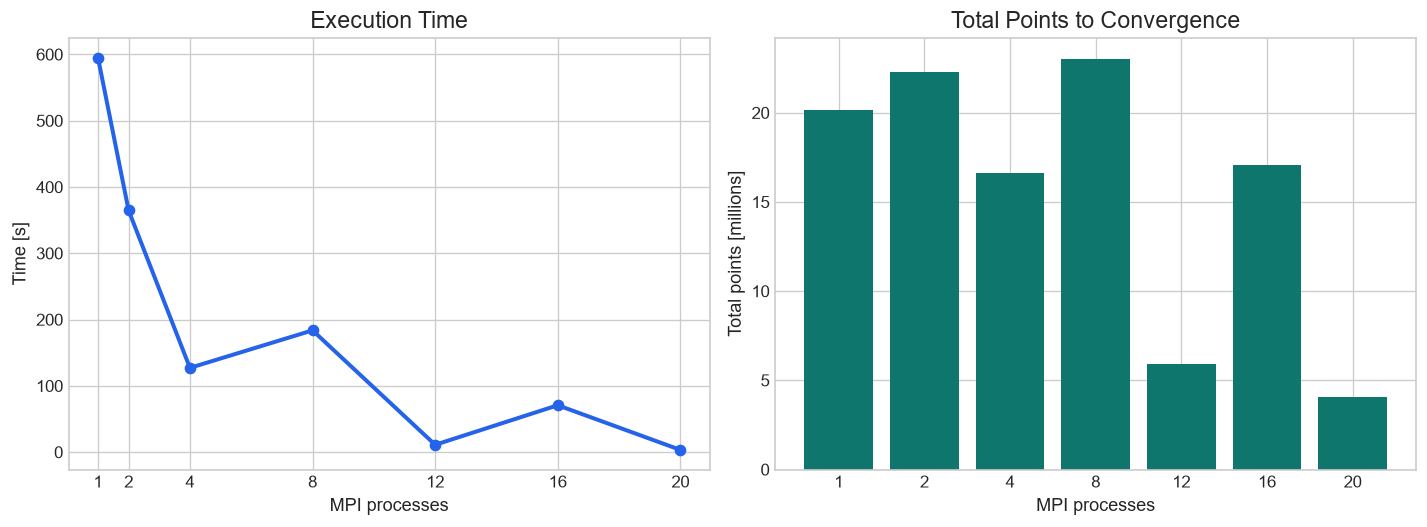

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(processes, times, marker="o", linewidth=2.4, color="#2563eb")
axes[0].set_title("Execution Time")
axes[0].set_xlabel("MPI processes")
axes[0].set_ylabel("Time [s]")
axes[0].set_xticks(processes)

axes[1].bar([str(process) for process in processes], total_points_millions, color="#0f766e")
axes[1].set_title("Total Points to Convergence")
axes[1].set_xlabel("MPI processes")
axes[1].set_ylabel("Total points [millions]")

fig.tight_layout()
plt.show()


The execution time decreases strongly when the number of MPI processes increases, especially for 12 and 20 processes. However, the second plot shows that the total number of sampled points is not constant across runs. Since the simulation stops when the estimated value of pi reaches the convergence threshold, some runs terminate earlier than others. Therefore, the reduction in execution time is due to both parallelism and a variable workload.

## Speedup and Efficiency

The ideal speedup line assumes a fixed-size problem. Since this experiment uses convergence-based stopping, deviations from ideal behavior must be interpreted carefully even though the notebook now uses the standard reference run with 1 MPI process.

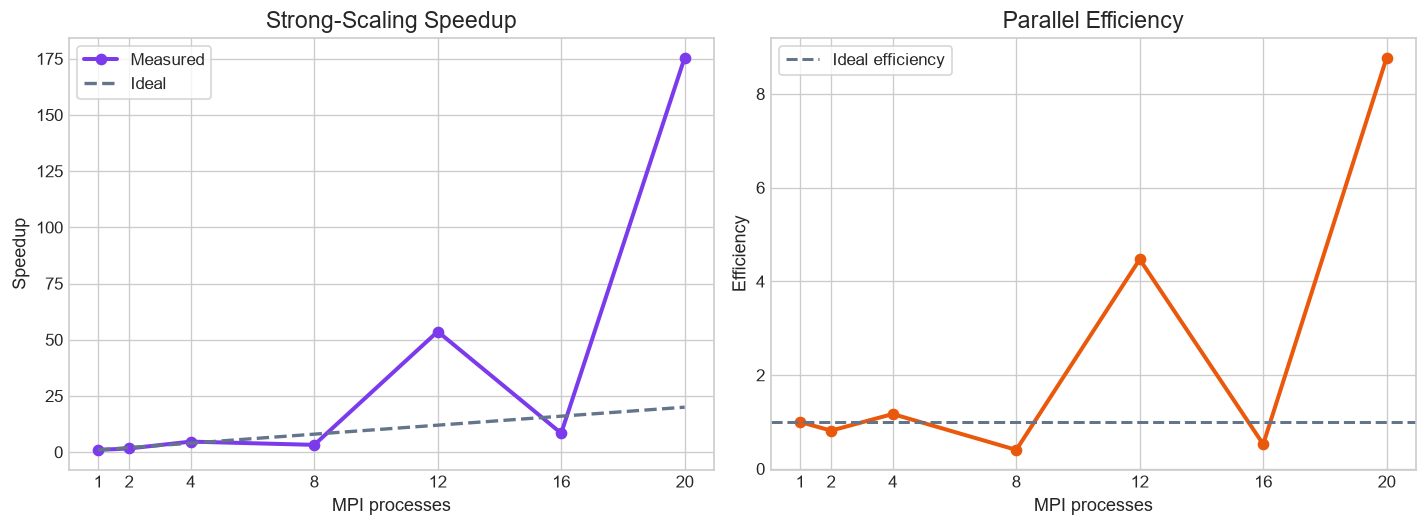

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(processes, speedups, marker="o", linewidth=2.4, label="Measured", color="#7c3aed")
axes[0].plot(processes, ideal_speedups, linestyle="--", linewidth=2, label="Ideal", color="#64748b")
axes[0].set_title("Strong-Scaling Speedup")
axes[0].set_xlabel("MPI processes")
axes[0].set_ylabel("Speedup")
axes[0].set_xticks(processes)
axes[0].legend()

axes[1].plot(processes, efficiencies, marker="o", linewidth=2.4, color="#ea580c")
axes[1].axhline(1.0, linestyle="--", linewidth=1.8, color="#64748b", label="Ideal efficiency")
axes[1].set_title("Parallel Efficiency")
axes[1].set_xlabel("MPI processes")
axes[1].set_ylabel("Efficiency")
axes[1].set_xticks(processes)
axes[1].legend()

fig.tight_layout()
plt.show()

The speedup is now computed with the standard strong-scaling definition, using the 1-process execution time as the reference. However, the measured speedup does not follow the ideal trend in a regular way. In particular, the very large values at 12 and 20 processes are amplified by the fact that those runs required fewer total Monte Carlo points to converge. For the same reason, the efficiency can exceed 1, which should not be interpreted as true superlinear scaling of the parallel algorithm. Instead, it reflects the combination of parallel execution and a reduced effective workload.

## Throughput Analysis

Throughput is the most robust metric for this dataset because it accounts for the different amount of work performed in each run. It measures how many Monte Carlo samples are processed per second.

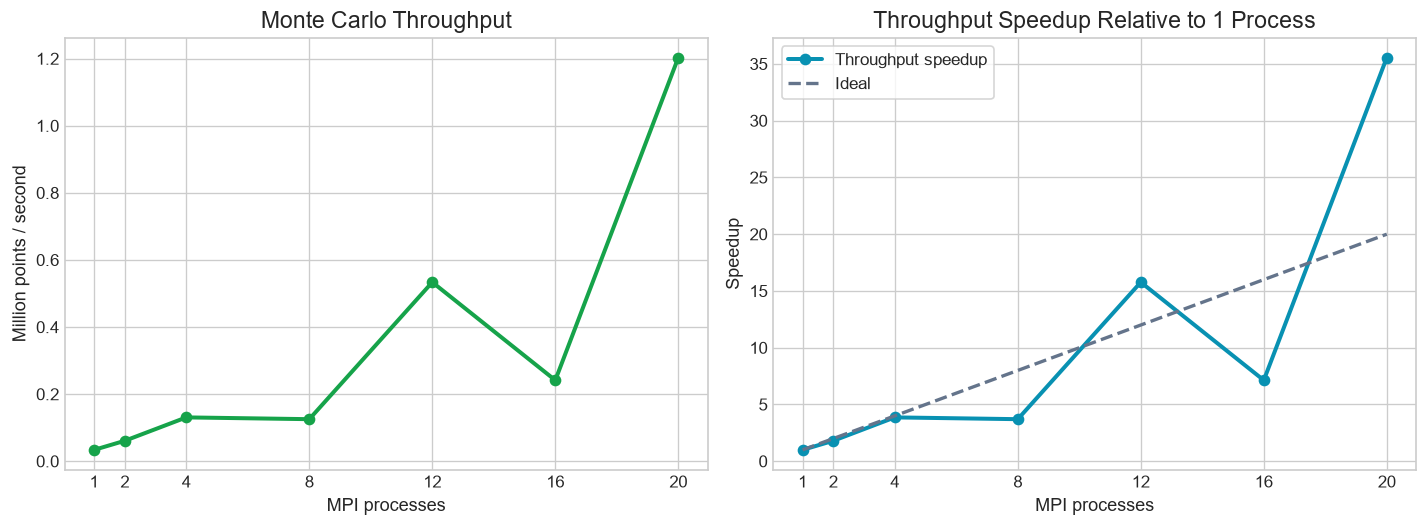

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(processes, throughput_millions, marker="o", linewidth=2.4, color="#16a34a")
axes[0].set_title("Monte Carlo Throughput")
axes[0].set_xlabel("MPI processes")
axes[0].set_ylabel("Million points / second")
axes[0].set_xticks(processes)

axes[1].plot(processes, throughput_speedups, marker="o", linewidth=2.4, label="Throughput speedup", color="#0891b2")
axes[1].plot(processes, ideal_speedups, linestyle="--", linewidth=2, label="Ideal", color="#64748b")
axes[1].set_title("Throughput Speedup Relative to 1 Process")
axes[1].set_xlabel("MPI processes")
axes[1].set_ylabel("Speedup")
axes[1].set_xticks(processes)
axes[1].legend()

fig.tight_layout()
plt.show()

Throughput is the most informative metric for this dataset because it measures how many Monte Carlo samples are processed per second. Unlike raw execution time, it partially accounts for the different amount of work performed in each run. The throughput generally improves compared with the 1-process case, showing that the MPI implementation increases computational capacity. At the same time, the trend is not perfectly monotonic, which confirms that parallel performance is still influenced by the variable number of points required for convergence.

## Numerical Accuracy

All runs estimate pi with a small absolute error. This confirms that the parallel runs reach the requested numerical target, while the previous plots focus on the cost of reaching that target.

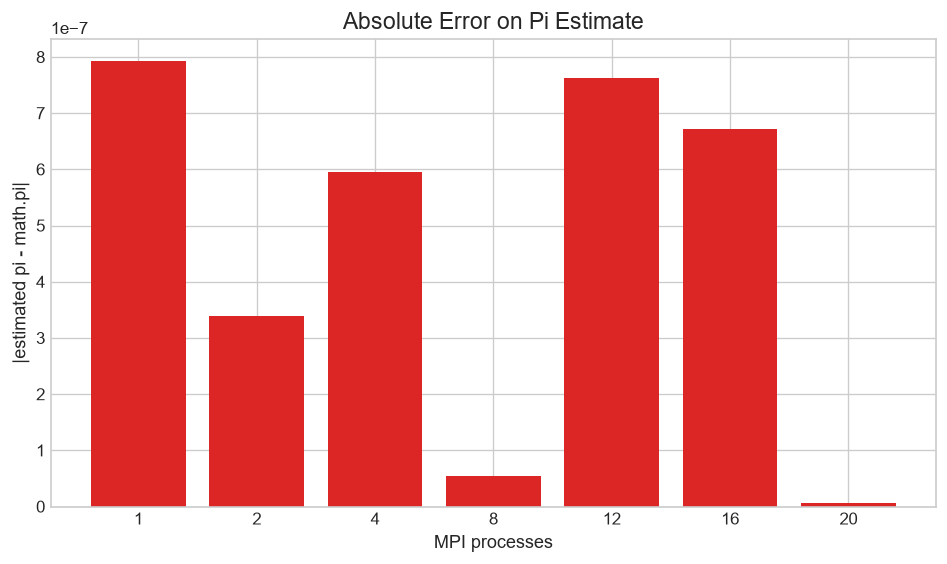

In [8]:
pi_errors = [run["pi_absolute_error"] for run in runs]

fig, ax = plt.subplots(figsize=(8, 4.8))

ax.bar([str(process) for process in processes], pi_errors, color="#dc2626")
ax.set_title("Absolute Error on Pi Estimate")
ax.set_xlabel("MPI processes")
ax.set_ylabel("|estimated pi - math.pi|")
ax.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))

plt.tight_layout()
plt.show()

All runs produce a very small absolute error on pi, of the order of 10^-7 or lower. This confirms that the numerical target is reached consistently across all tested process counts. The main difference between runs is therefore not accuracy, but the amount of work and time required to achieve that accuracy.

## Discussion

The MPI implementation distributes the Monte Carlo sampling work across independent processes. The root process broadcasts the configuration parameters, each process computes its local count of accepted random points, and a collective `Reduce` operation sums the partial results.

The execution time generally improves when more processes are used, especially for the runs with 12 and 20 MPI processes. However, those runs also required fewer total points to reach convergence. For this reason, the speedup and efficiency plots should not be interpreted as a strict strong-scaling measurement even though they now use the standard reference run with 1 MPI process.

The throughput plot gives a clearer view of computational capacity: it shows the number of Monte Carlo samples processed per second. This is useful when the workload changes between runs, because it normalizes the timing by the actual number of processed points.

For this reason, the present results should be interpreted as a strong-scaling analysis based on the standard reference run with 1 MPI process, but not as a perfectly controlled benchmark with fixed problem size.

For a fully controlled strong-scaling study, the next step would be to repeat the benchmark with a fixed number of total points for every process count, then compare the execution times directly.